In [1]:
import scanpy as sc
from time import time
import pandas as pd
import tqdm
import numpy as np 
import gc
import anndata as ad
import matplotlib.pyplot as plt

In [2]:
import os, sys
os.environ['R_HOME'] = sys.exec_prefix+"/lib/R/"
import scFates as scf
import palantir

In [3]:
DATA_PATH="/home/felix/data/translation_control"

In [4]:
adata=sc.read(f"{DATA_PATH}/anndata/adata_glia_scrubbed.h5ad")
sc.set_figure_params(figsize=(9,3))

In [5]:
adata.obs

,sample,dataset,devtime,location,n_genes_by_counts,total_counts,total_counts_ERCC,pct_counts_ERCC,doublet_scores,predicted_doublets
E24_SS2_15_0073,E24,SS2_15_0073,E12.5,Cranial,11839,528117.000000,42552.0,8.057305,0.114416,False
G2_SS2_15_0073,G2,SS2_15_0073,E12.5,Cranial,9225,251415.984375,24521.0,9.753159,0.137306,False
M17_SS2_15_0073,M17,SS2_15_0073,E12.5,Cranial,12650,487904.000000,28720.0,5.886404,0.054764,False
L24_SS2_15_0073,L24,SS2_15_0073,E12.5,Cranial,10646,430012.968750,35324.0,8.214636,0.377522,False
C5_SS2_15_0073,C5,SS2_15_0073,E12.5,Cranial,10635,337417.000000,23872.0,7.074925,0.121429,False
...,...,...,...,...,...,...,...,...,...,...
A15_SS2_19_372,A15,SS2_19_372,E10.5,Trunk,13285,391143.000000,56.0,0.014317,0.200000,False
D24_SS2_19_372,D24,SS2_19_372,E10.5,Trunk,13633,283347.000000,39.0,0.013764,0.156250,False
I18_SS2_19_372,I18,SS2_19_372,E10.5,Trunk,13719,334413.000000,65.0,0.019437,0.114416,False
H24_SS2_19_372,H24,SS2_19_372,E10.5,Trunk,13039,267340.000000,62.0,0.023191,0.291667,False


In [6]:
adata.var

,gene,transcript,ERCC,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
ENSMUST00000193812.2,4933401J01Rik,4933401J01Rik-201,False,18,0.007245,99.903402,1.350000e+02
ENSMUST00000082908.3,Gm26206,Gm26206-201,False,8,0.001020,99.957068,1.900000e+01
ENSMUST00000162897.2,Xkr4,Xkr4-203,False,1007,0.872439,94.595900,1.625702e+04
ENSMUST00000159265.2,Xkr4,Xkr4-202,False,288,0.188144,98.454438,3.505881e+03
ENSMUST00000070533.5,Xkr4,Xkr4-201,False,606,0.675223,96.747880,1.258210e+04
...,...,...,...,...,...,...,...
ENSMUST00000082419.1,mt-Nd6,mt-Nd6-201,False,17979,102.830740,3.515080,1.916148e+06
ENSMUST00000082420.1,mt-Te,mt-Te-201,False,0,0.000000,100.000000,0.000000e+00
ENSMUST00000082421.1,mt-Cytb,mt-Cytb-201,False,18448,2759.691585,0.998175,5.142254e+07
ENSMUST00000082422.1,mt-Tt,mt-Tt-201,False,6795,0.679028,63.534399,1.265300e+04


In [7]:
sc.set_figure_params()
sc.pp.filter_genes(adata,min_cells=3)
sc.pp.normalize_total(adata,target_sum=1e3)
sc.pp.log1p(adata)

In [8]:
from rpy2.robjects import pandas2ri
pandas2ri.activate()

Finding overdispersed features
    computing mean and variances
    gam fitting
    found 37062 over-dispersed features (0:00:09) --> added 
    .var['res'], residuals of GAM fit.
    .var['lp'], p-value.
    .var['lpa'], BH adjusted p-value.
    .var['qv'], percentile of qui-squared distribution.
    .var['highly_variable'], feature is over-dispersed.



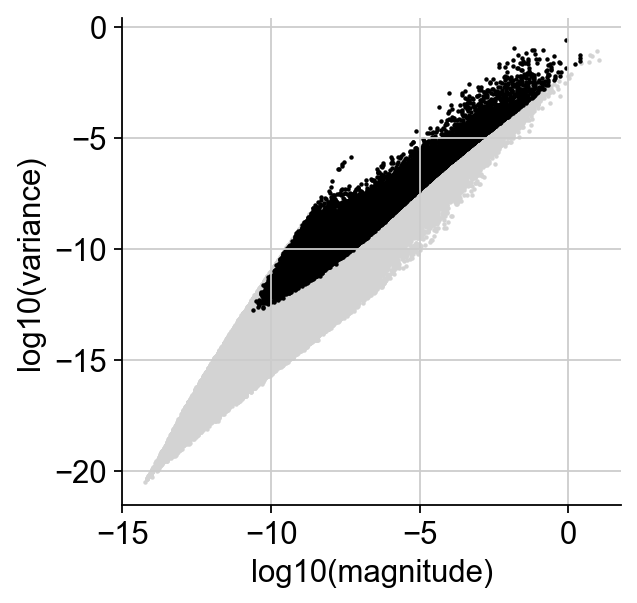

In [9]:
scf.pp.find_overdispersed(adata,plot=True)

In [10]:
adata.layers["scaled"]=sc.pp.scale(adata.X,max_value=10,copy=True)
adata.obsm["X_pca"]=sc.pp.pca(adata[:,adata.var.highly_variable].layers["scaled"])

/home/felix/miniconda3/envs/scFates/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [11]:
sc.pp.neighbors(adata,n_neighbors=30,n_pcs=30,metric="cosine") # Replaced with previous processing

/home/felix/miniconda3/envs/scFates/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
sc.tl.umap(adata)
sc.tl.leiden(adata)

/tmp/ipykernel_8849/1561440278.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


In [13]:
adata.obs

,sample,dataset,devtime,location,n_genes_by_counts,total_counts,total_counts_ERCC,pct_counts_ERCC,doublet_scores,predicted_doublets,leiden
E24_SS2_15_0073,E24,SS2_15_0073,E12.5,Cranial,11839,528117.000000,42552.0,8.057305,0.114416,False,16
G2_SS2_15_0073,G2,SS2_15_0073,E12.5,Cranial,9225,251415.984375,24521.0,9.753159,0.137306,False,16
M17_SS2_15_0073,M17,SS2_15_0073,E12.5,Cranial,12650,487904.000000,28720.0,5.886404,0.054764,False,16
L24_SS2_15_0073,L24,SS2_15_0073,E12.5,Cranial,10646,430012.968750,35324.0,8.214636,0.377522,False,7
C5_SS2_15_0073,C5,SS2_15_0073,E12.5,Cranial,10635,337417.000000,23872.0,7.074925,0.121429,False,21
...,...,...,...,...,...,...,...,...,...,...,...
A15_SS2_19_372,A15,SS2_19_372,E10.5,Trunk,13285,391143.000000,56.0,0.014317,0.200000,False,12
D24_SS2_19_372,D24,SS2_19_372,E10.5,Trunk,13633,283347.000000,39.0,0.013764,0.156250,False,10
I18_SS2_19_372,I18,SS2_19_372,E10.5,Trunk,13719,334413.000000,65.0,0.019437,0.114416,False,10
H24_SS2_19_372,H24,SS2_19_372,E10.5,Trunk,13039,267340.000000,62.0,0.023191,0.291667,False,12


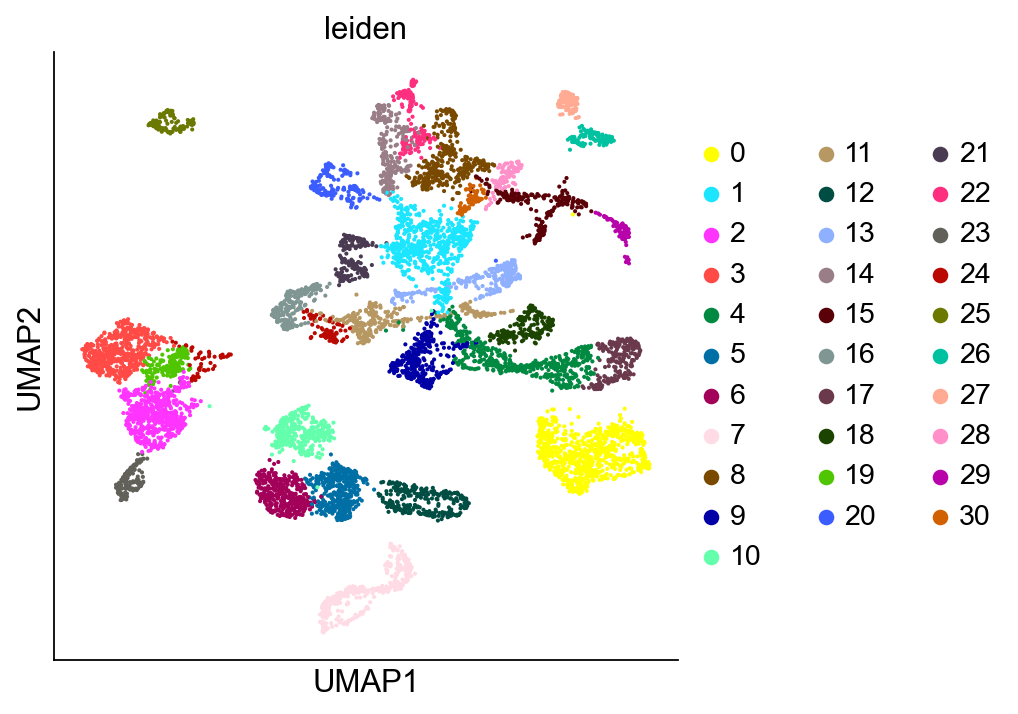

In [14]:
sc.set_figure_params(figsize=(5,5))
sc.pl.umap(adata, color="leiden")

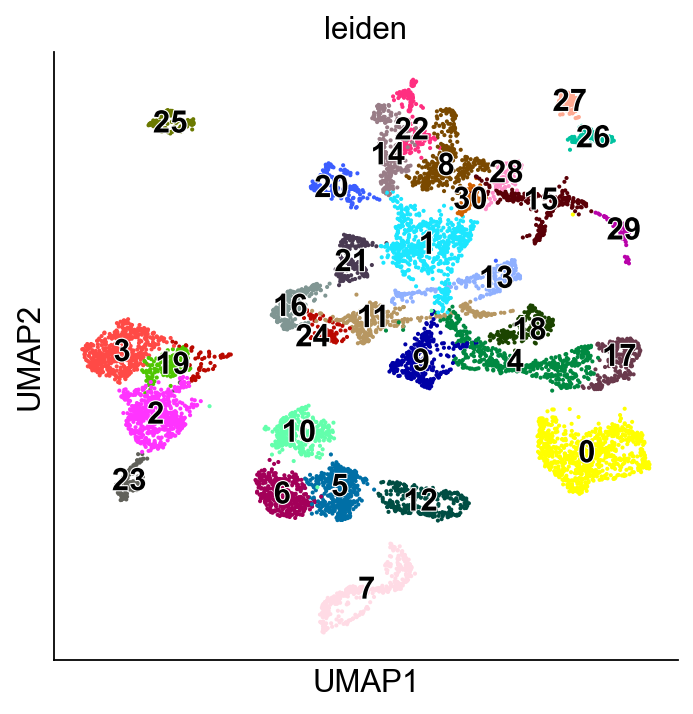

In [15]:
sc.pl.umap(adata,color="leiden",legend_loc="on data",legend_fontoutline=True)

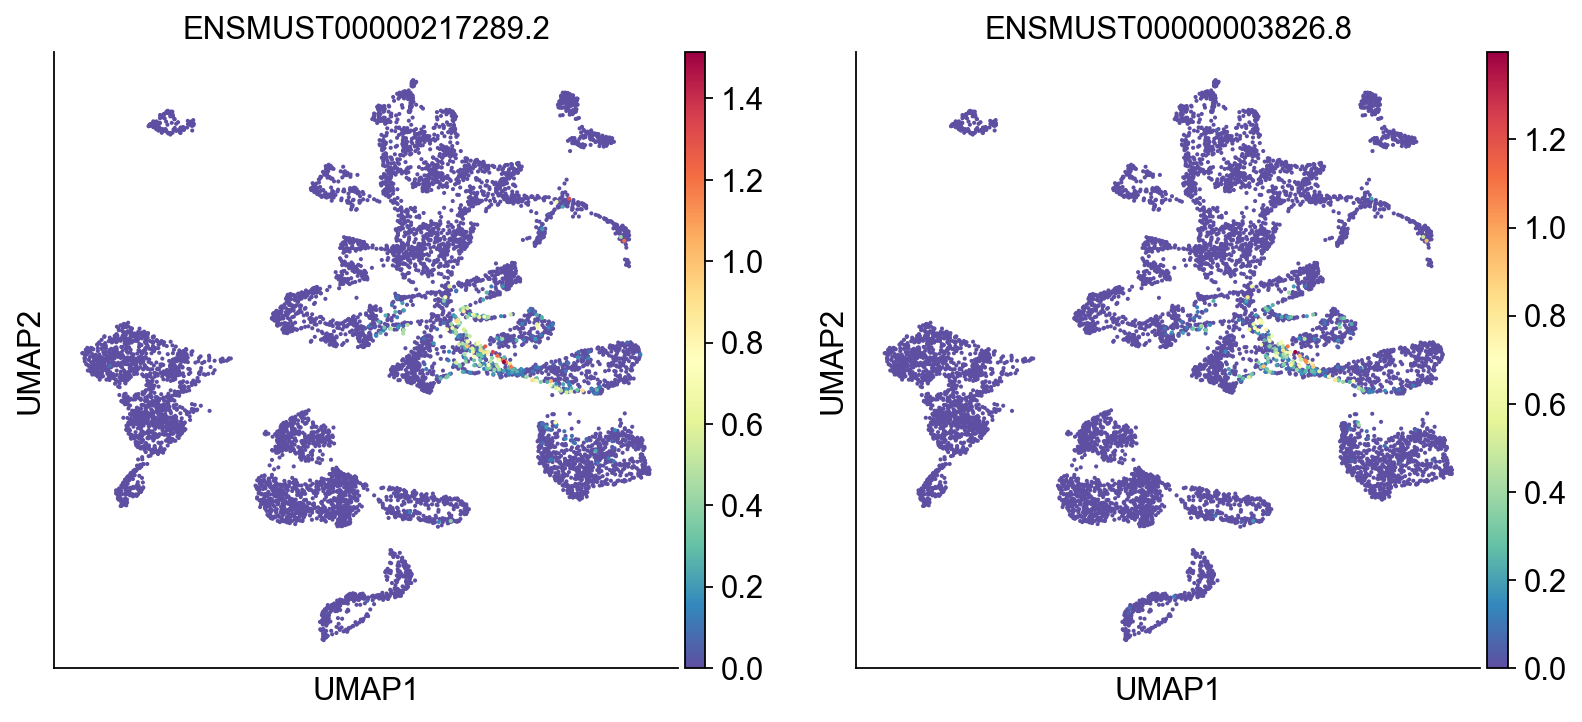

In [16]:
sc.pl.umap(adata,color=adata.var[adata.var.gene=="Htr3a"].index.tolist())

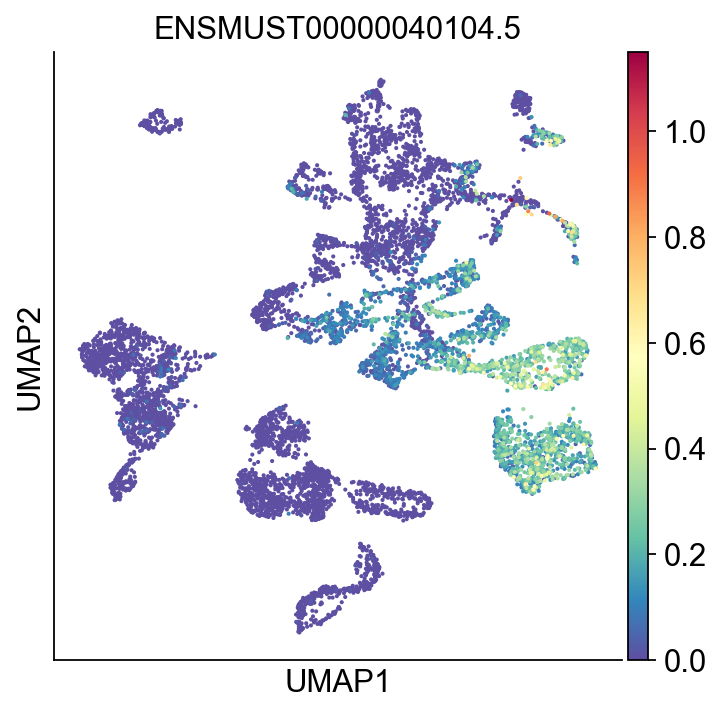

In [17]:
sc.pl.umap(adata,color=adata.var[adata.var.gene=="Hand2"].index.tolist())

In [18]:
adata

AnnData object with n_obs × n_vars = 8749 × 193384
    obs: 'sample', 'dataset', 'devtime', 'location', 'n_genes_by_counts', 'total_counts', 'total_counts_ERCC', 'pct_counts_ERCC', 'doublet_scores', 'predicted_doublets', 'leiden'
    var: 'gene', 'transcript', 'ERCC', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'm', 'v', 'n_obs', 'res', 'lp', 'lpa', 'qv', 'highly_variable'
    uns: 'log1p', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'abundance', 'length', 'scaled'
    obsp: 'distances', 'connectivities'

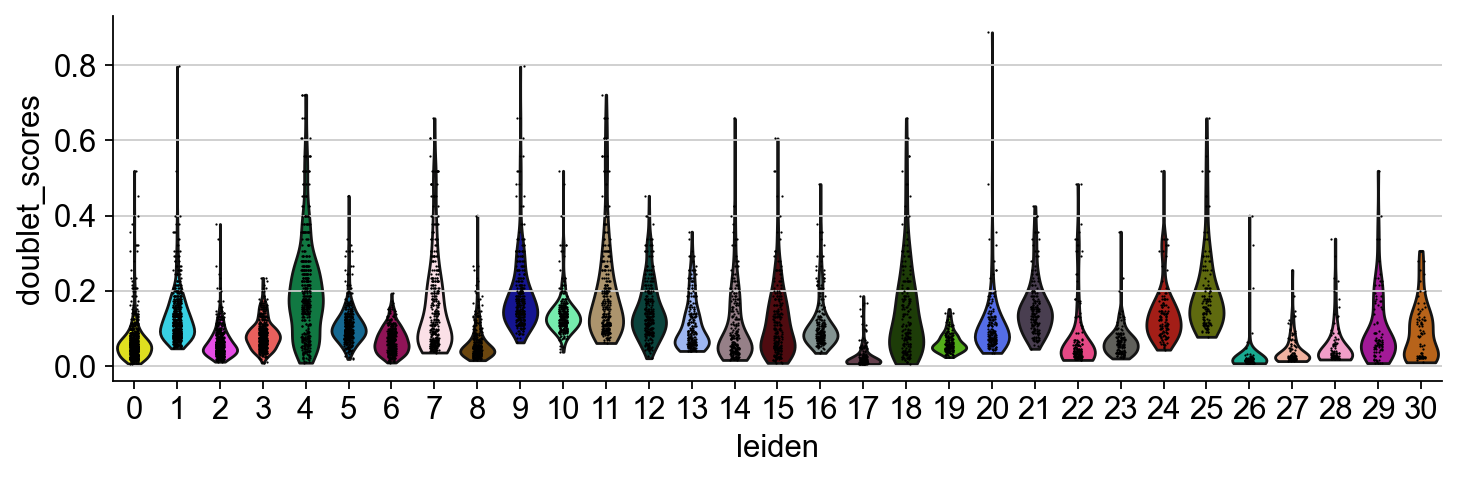

In [19]:
sc.set_figure_params(figsize=(9,3))
sc.pl.violin(adata,
             "doublet_scores",
             "leiden")

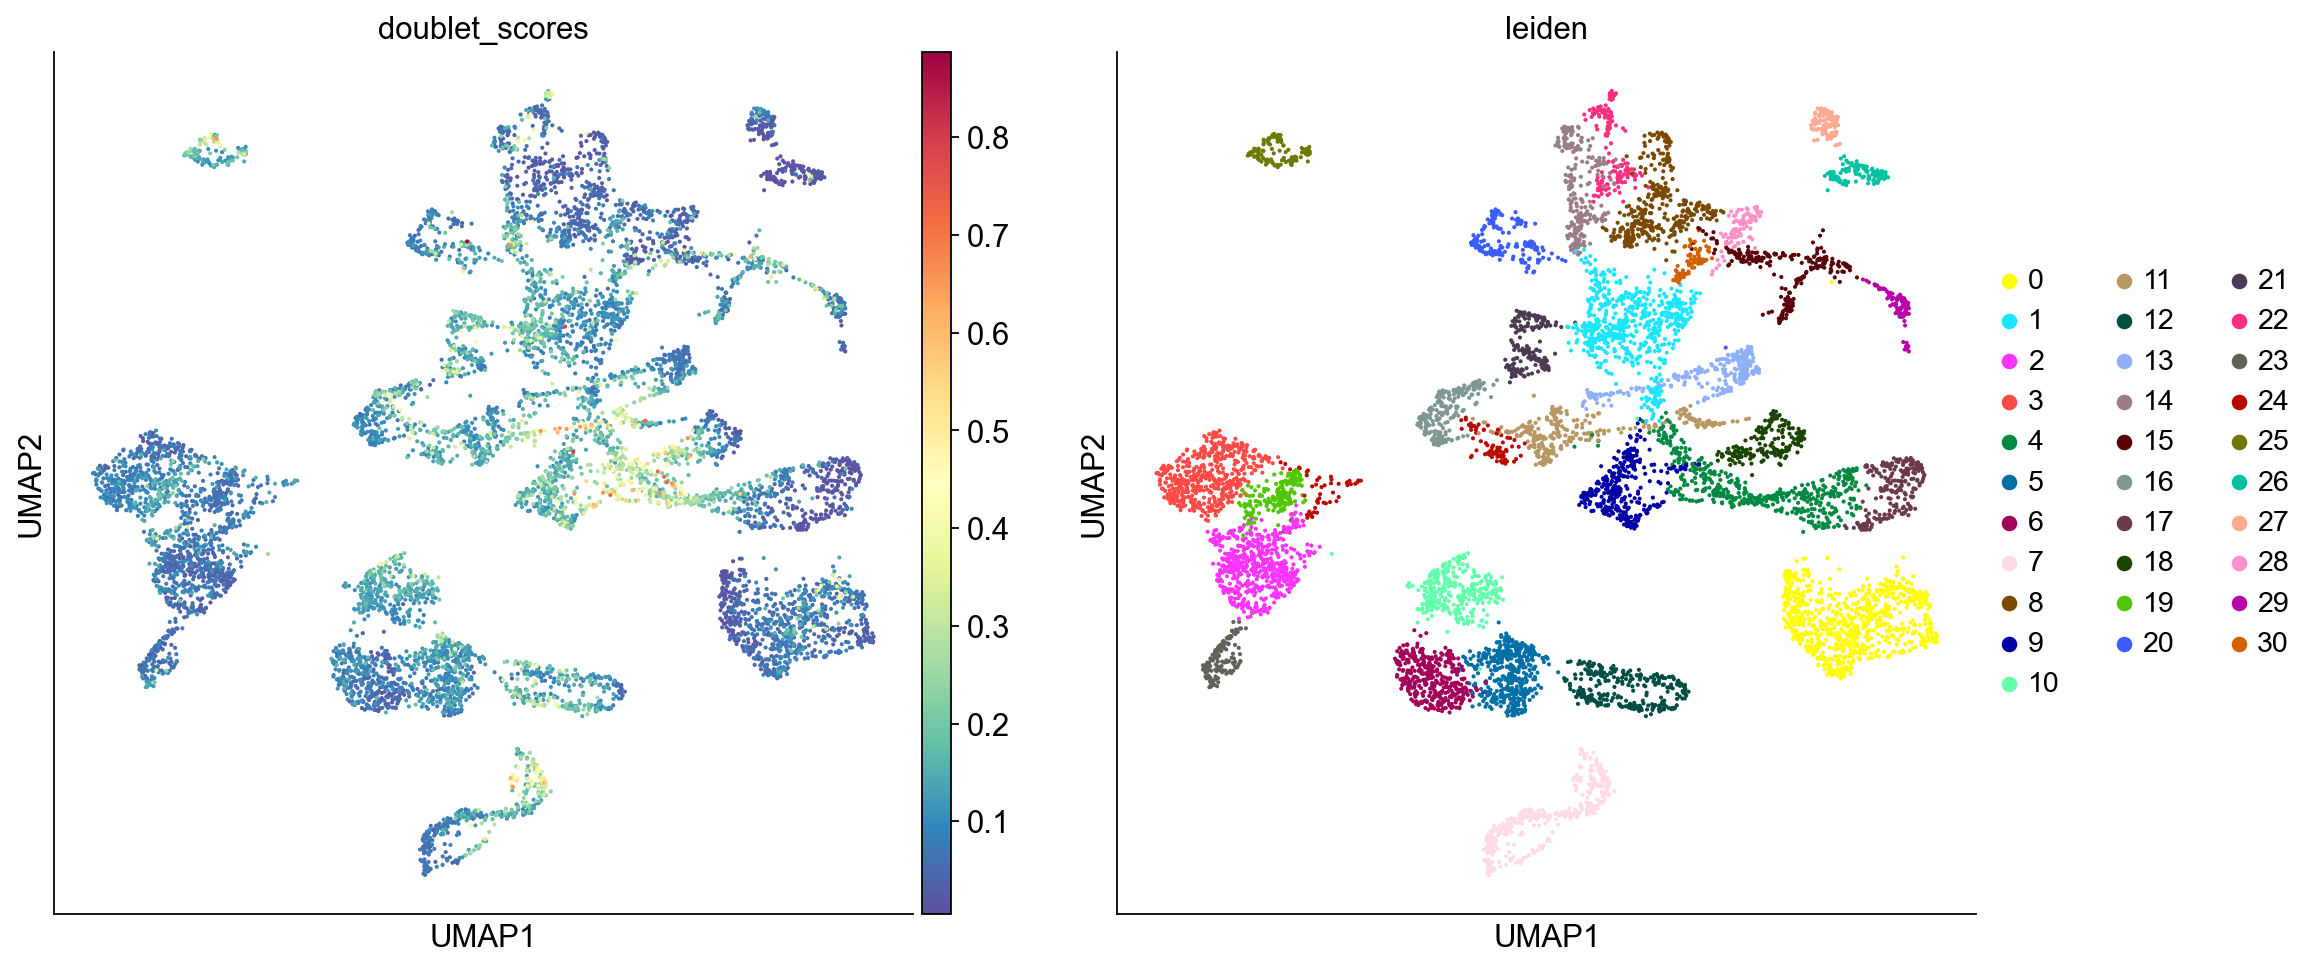

In [20]:
sc.set_figure_params(figsize=(7,7))

sc.pl.umap(adata,color=["doublet_scores", "leiden"])

**A lot of my clusters have a bit higher doublet score but non actually have it as high as in Louises notebook. Therefore I will not filter in like he does. Perhaps I should simply filter on a cell level if a doublet score exceeds something.**

In [21]:
print(adata.shape)
adata=adata[adata.obs.predicted_doublets==False]
print(adata.shape)

(8749, 193384)
(8746, 193384)


In [22]:
#sc.set_figure_params(dpi=150)
#adata=adata[~adata.obs.leiden.isin(["30","31"])] # Chose the ones with divergent doublet score.


In [ ]:
sc.set_figure_params(figsize=(5,5))
sc.pp.filter_genes(adata,min_cells=3)
scf.pp.find_overdispersed(adata,plot=True)
adata.layers["scaled"]=sc.pp.scale(adata.X,max_value=10,copy=True)
adata.obsm["X_pca"]=sc.pp.pca(adata[:,adata.var.highly_variable].layers["scaled"])
sc.pp.neighbors(adata,metric="cosine",n_pcs=30)

/home/felix/miniconda3/envs/scFates/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [ ]:
import pandas as pd
import palantir
dm_res = palantir.utils.run_diffusion_maps(pd.DataFrame(adata.obsm["X_pca"][:,:50],index=adata.obs_names),knn=80)
#ms_data = palantir.utils.determine_multiscale_space(dm_res,n_eigs=10)
adata.obsm["X_diff"]=dm_res["EigenVectors"].iloc[:,1:9].values

In [ ]:
import cuml

In [ ]:
#sc.pp.neighbors(adata,n_neighbors=40,
#                use_rep="X_diff",
#                method="rapids") # Rapids is outdated so might need to remove.

sc.pp.neighbors(adata,n_neighbors=40,
                use_rep="X_diff",
                method="umap") # Rapids is outdated so might need to remove.


In [ ]:
sc.tl.paga(adata,"leiden")
sc.pl.paga(adata,threshold=.02)

In [ ]:
sc.pp.neighbors(adata,n_neighbors=80,
                use_rep="X_diff",
                method="umap" # Used to be rapids
               )


In [ ]:
sc.tl.umap(adata,spread=.6,init_pos="paga")

In [ ]:
sc.set_figure_params(figsize=(7,7))
sc.pl.umap(adata)

In [ ]:
sc.pl.umap(adata,color="leiden")

In [ ]:
from scipy.sparse import csr_matrix
adata.X=csr_matrix(np.e**adata.X.toarray()-1)
sc.pp.normalize_total(adata,target_sum=1e6)
sc.pp.log1p(adata,base=10)

In [ ]:
import gc
gc.collect()

In [ ]:
imp_df = palantir.utils.run_magic_imputation(pd.DataFrame(adata.X.toarray(),
                                                          index=adata.obs_names,
                                                          columns=adata.var_names), dm_res)

In [ ]:
adata.layers["palantir_imp"]=csr_matrix(imp_df.values)

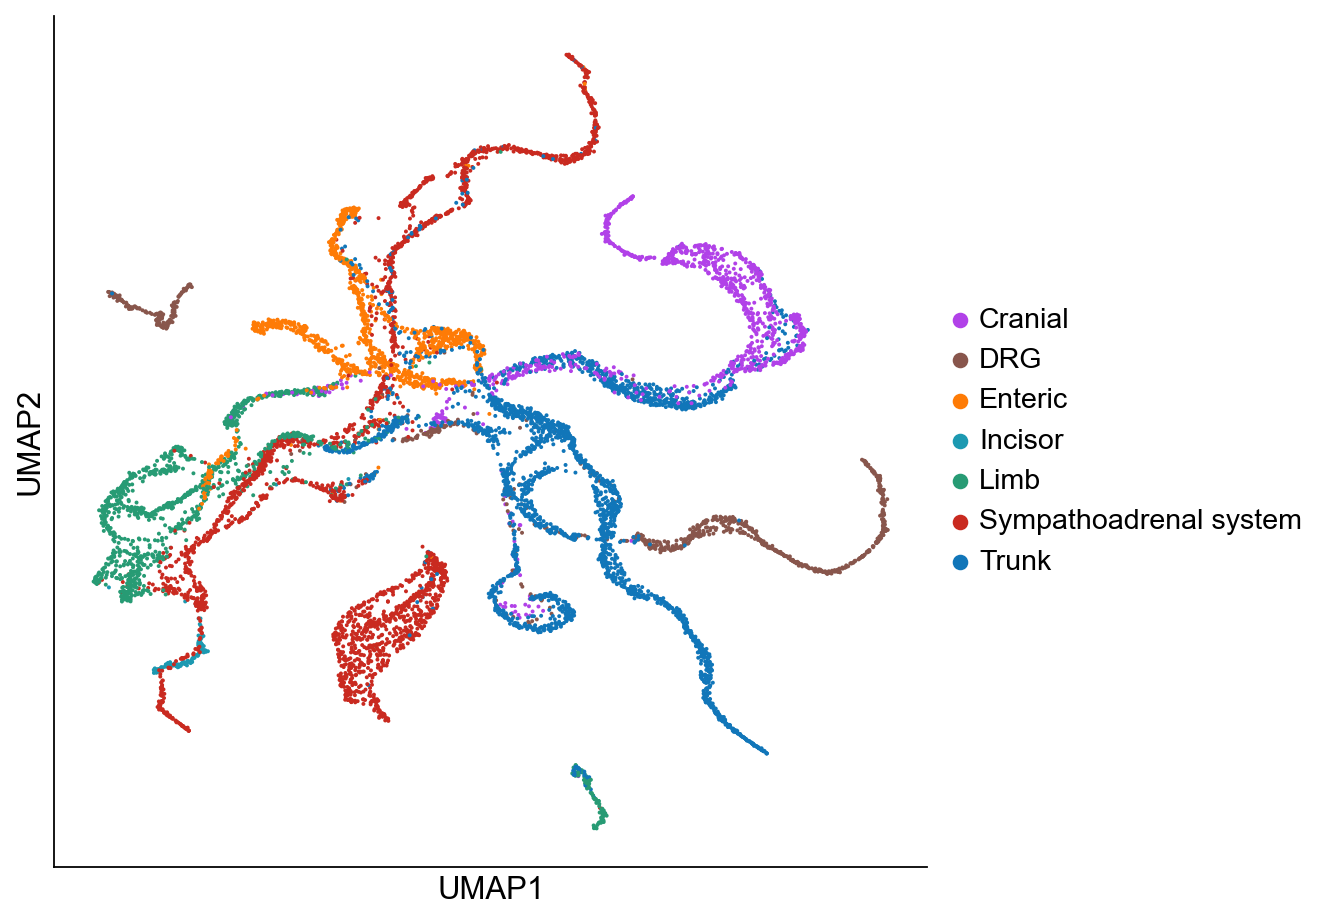

In [36]:
sc.pl.umap(adata,color="location",
           palette=["#B141E8","#88564C","#FE7B06","#1C99B1","#279B74","#C92A20","#1176B9"],
           title="")


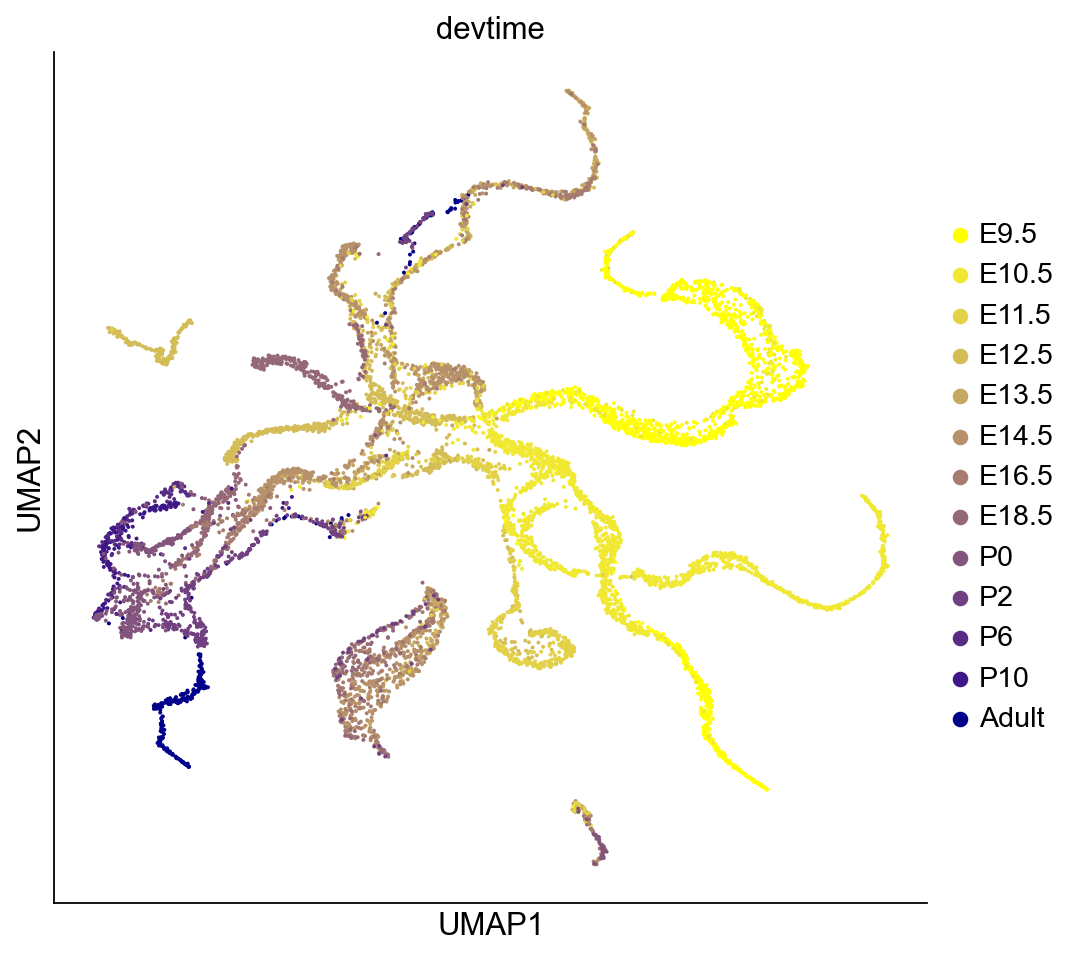

In [37]:
adata.obs.devtime=adata.obs.devtime.cat.reorder_categories(['E9.5',
                                                            'E10.5',
                                                            'E11.5',
                                                            'E12.5',
                                                            'E13.5',
                                                            'E14.5',
                                                            'E16.5',
                                                            'E18.5',
                                                            'P0',
                                                            'P2',
                                                            'P6',
                                                            'P10',
                                                            "Adult"])
dev_pal=["#FFFF00",
         "#F1E834",
         "#E3D248",
         "#D4BC56",
         "#C5A761",
         "#B69169",
         "#A67C70",
         "#956876",
         "#83547C",
         "#704080",
         "#592C84",
         "#3D1788",
         "#00008B"]
sc.pl.umap(adata,color="devtime",palette=dev_pal)

In [38]:
# To minimise rerun times
adata.write(f"{DATA_PATH}/anndata/adata_before_cytotrace.h5ad")


### Cytotrace crashes due to memory constraints. To mitigate this try.
1. Reduce number of cores.
2. Process in chunks. 

'Split your data into smaller chunks'
'chunk_size = 5000'
'results_list = []'

'for i in range(0, adata.n_obs, chunk_size):'

    '    chunk = adata[i:i+chunk_size, :]'

    '    chunk_results = CytoTRACE(chunk.X, ncores=4)  # Reduce cores if needed'

    '    results_list.append(chunk_results)''
3. Test CYTOTRACE2, this has a python port as well. And is suppose to just be more accurate 


In [41]:
import rpy2
import anndata2ri
anndata2ri.activate()
%load_ext rpy2.ipython

/tmp/ipykernel_11274/2909349582.py:3: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [ ]:
%%R -i adata -o ct
source("CytoTRACE.R")
rownames(adata@assays@data$X)=rownames(adata)
colnames(adata@assays@data$X)=colnames(adata)
results=CytoTRACE(adata@assays@data$X,ncores=4)
ct=results$CytoTRACE

In [ ]:
adata.obs["CytoTRACE"]=ct


In [38]:
import cytotrace2_py

In [40]:
# Help from Claude 4.0 Sonnet
# It seems to missinterpret use.
results = cytotrace2_py.cytotrace2(
    adata,
    species='mouse',  
)

# For large datasets, use subsampling
#results = cytotrace2_py.cytotrace2(
#    adata,
#    species='mouse',
#    subsample_size=10000,  # Subsample to 10k cells
#    use_full_bior=True
#)


cytotrace2: Input parameters


TypeError: can only concatenate str (not "AnnData") to str

In [ ]:
# Add results back to your adata object
adata.obs['CytoTRACE2_Score'] = results['CytoTRACE2_Score']
adata.obs['CytoTRACE2_Potency'] = results['CytoTRACE2_Potency']

In [ ]:
sc.pl.umap(adata,color="CytoTRACE2_Score",cmap="Spectral_r")


In [ ]:
sc.pl.umap(adata,color="CytoTRACE",cmap="Spectral_r")


In [ ]:
adata.write(f"{DATA_PATH}/anndata/adata_processed.h5ad")
